test cell

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output, Markdown
import io

# ==========================================
# 1. SETUP & ALGORITHMS (From your group's code)
# ==========================================
# We define the KNN algorithm here exactly as your group did.
def knn_predict_one(x, X_train, y_train, k):
    # Calculate distance between x and all training points
    dists = np.sqrt(np.sum((X_train - x) ** 2, axis=1))
    # Find the k nearest neighbors
    k_idx = np.argsort(dists)[:k]
    # Vote on the label
    labels, counts = np.unique(y_train[k_idx], return_counts=True)
    return labels[np.argmax(counts)]

# ==========================================
# 2. DATA LOADING & TRAINING
# ==========================================
try:
    # Load the dataset
    # We use the same columns your group selected in 'testingcolumn.py'
    # Columns: 0=Checking, 1=Duration, 2=History, 3=Purpose, 4=Amount, 
    #          5=Savings, 6=Employment, 8=Sex/Status, 11=Property, 14=Housing
    important_cols = [0, 1, 2, 3, 4, 5, 6, 8, 11, 14]
    
    # Load data (assuming german.data is in the folder)
    data = pd.read_csv("german.data", header=None, delim_whitespace=True)
    
    # Prepare X (Features) and y (Labels)
    X_df = data.iloc[:, important_cols].copy()
    y = data.iloc[:, -1].values  # 1 = Good, 2 = Bad

    # ENCODING: We need to turn text codes (A11, A12) into numbers for the math to work
    # We save the "mappings" so we can translate user input later
    encoders = {} 
    for col_idx in X_df.columns:
        if X_df[col_idx].dtype == "object":
            # Convert to category and then to code
            X_df[col_idx] = X_df[col_idx].astype("category")
            encoders[col_idx] = dict(enumerate(X_df[col_idx].cat.categories))
            X_df[col_idx] = X_df[col_idx].cat.codes

    X = X_df.values.astype(float)
    
    # Split Data (Train/Test)
    np.random.seed(42)
    indices = np.random.permutation(len(X))
    split = int(len(X) * 0.7) # 70% Training
    train_idx, test_idx = indices[:split], indices[split:]
    X_train, y_train = X[train_idx], y[train_idx]
    
    # Pre-calculate a Confusion Matrix for the "Stats" tab
    # We use a small subset to keep it fast for the demo
    demo_preds = [knn_predict_one(x, X_train, y_train, k=5) for x in X[test_idx[:50]]]
    demo_actual = y[test_idx[:50]]
    
except Exception as e:
    print(f"Error loading data: {e}")
    print("Make sure 'german.data' is in the same folder as this notebook.")
    X_train = [] # Prevent crash if file missing

# ==========================================
# 3. USER INTERFACE (WIDGETS)
# ==========================================

# --- Styling ---
style = {'description_width': '150px'}
layout = widgets.Layout(width='400px', margin='5px')

# --- Header ---
header = widgets.HTML("<h2>🏦 German Credit Risk System</h2>")
desc = widgets.HTML("Use the tabs below to predict credit risk or analyze the dataset.")

# --- Tab 1: Predictor Inputs ---
# We map the technical column names to readable labels
w_checking = widgets.Dropdown(options=['< 0 DM', '0 <= ... < 200 DM', '>= 200 DM', 'No checking account'], description='Checking Status:', style=style, layout=layout)
w_duration = widgets.IntSlider(value=24, min=4, max=72, description='Duration (Months):', style=style, layout=layout)
w_history = widgets.Dropdown(options=['No credits taken', 'All paid back', 'Existing credits paid', 'Delay in past', 'Critical account'], description='Credit History:', style=style, layout=layout)
w_purpose = widgets.Dropdown(options=['Car (New)', 'Car (Used)', 'Furniture', 'Radio/TV', 'Appliances', 'Repairs', 'Education', 'Business', 'Retraining'], description='Purpose:', style=style, layout=layout)
w_amount = widgets.IntText(value=3000, description='Credit Amount (DM):', style=style, layout=layout)
w_savings = widgets.Dropdown(options=['< 100 DM', '100 <= ... < 500 DM', '500 <= ... < 1000 DM', '>= 1000 DM', 'Unknown/No Savings'], description='Savings:', style=style, layout=layout)
w_employ = widgets.Dropdown(options=['Unemployed', '< 1 year', '1 <= ... < 4 years', '4 <= ... < 7 years', '>= 7 years'], description='Employment:', style=style, layout=layout)
w_sex = widgets.Dropdown(options=['Male: Divorced/Separated', 'Female: Divorced/Separated/Married', 'Male: Single', 'Male: Married/Widowed', 'Female: Single'], description='Sex & Status:', style=style, layout=layout)
w_property = widgets.Dropdown(options=['Real Estate', 'Savings Agreement', 'Car / Other', 'Unknown / No Property'], description='Property:', style=style, layout=layout)
w_housing = widgets.Dropdown(options=['Rent', 'Own', 'For Free'], description='Housing:', style=style, layout=layout)

btn_predict = widgets.Button(description="Predict Risk", button_style='primary', icon='check', layout=widgets.Layout(width='200px'))
out_predict = widgets.Output()

# --- Tab 2: Visualizations ---
out_viz = widgets.Output()

def show_visuals():
    with out_viz:
        clear_output()
        if len(X_train) == 0: return
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
        
        # Plot 1: Credit Risk Counts
        unique, counts = np.unique(y, return_counts=True)
        colors = ['green' if u == 1 else 'red' for u in unique]
        ax1.bar(['Good (1)', 'Bad (2)'], counts, color=colors)
        ax1.set_title("Distribution of Credit Risk")
        
        # Plot 2: Credit Amount vs Duration
        # Scatter plot of first 100 points
        subset = data.iloc[:100]
        colors_scatter = ['green' if c == 1 else 'red' for c in subset.iloc[:, -1]]
        ax2.scatter(subset[1], subset[4], c=colors_scatter, alpha=0.6)
        ax2.set_xlabel("Duration (Months)")
        ax2.set_ylabel("Credit Amount")
        ax2.set_title("Amount vs Duration (Green=Good, Red=Bad)")
        
        plt.tight_layout()
        plt.show()

# --- Logic: Connecting Inputs to Model ---
def on_predict_click(b):
    with out_predict:
        clear_output()
        if len(X_train) == 0:
            print("Error: Model not trained (Data missing).")
            return

        print("Processing input...")
        
        # 1. Convert Dropdowns back to the integer codes the model expects
        # Note: This is a simplified mapping based on list index for the demo
        # In a real scenario, we would match exact keys.
        inputs = [
            w_checking.index, 
            w_duration.value,
            w_history.index, 
            w_purpose.index, 
            w_amount.value, 
            w_savings.index, 
            w_employ.index, 
            w_sex.index, 
            w_property.index, 
            w_housing.index
        ]
        
        input_array = np.array([inputs], dtype=float)
        
        # 2. Run the KNN Algorithm (k=5)
        prediction = knn_predict_one(input_array, X_train, y_train, k=5)
        
        # 3. Show Result
        if prediction == 1:
            display(widgets.HTML(f"<h3 style='color:green; border:2px solid green; padding:10px; border-radius:5px;'>✅ Prediction: GOOD Credit Risk</h3>"))
            print("The model suggests this applicant is likely to repay the loan.")
        else:
            display(widgets.HTML(f"<h3 style='color:red; border:2px solid red; padding:10px; border-radius:5px;'>⚠️ Prediction: BAD Credit Risk</h3>"))
            print("The model suggests this applicant is high risk.")

btn_predict.on_click(on_predict_click)

# --- Layout Assembly ---
input_col1 = widgets.VBox([w_checking, w_duration, w_history, w_purpose, w_amount])
input_col2 = widgets.VBox([w_savings, w_employ, w_sex, w_property, w_housing])
input_ui = widgets.VBox([
    widgets.HBox([input_col1, input_col2]),
    widgets.HTML("<br>"),
    btn_predict,
    out_predict
])

# Initialize tabs
tabs = widgets.Tab([input_ui, out_viz, slot_ui])
tabs.set_title(0, 'Risk Predictor')
tabs.set_title(1, 'Data Insights')
tabs.set_title(2, 'Slot Machine')

# Initialize visuals
show_visuals()

# Final Display
ui = widgets.VBox([header, desc, tabs])
display(ui)

C:\Users\lerya.DESKTOP-O4134LB\AppData\Local\Temp\ipykernel_10700\957291225.py:32: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv("german.data", header=None, delim_whitespace=True)


NameError: name 'slot_ui' is not defined

In [14]:
# ==========================================
# 4. SLOT MACHINE TAB
# ==========================================

slot_symbols = ['🎰', '💰', '🎯', '🍀', '⭐', '🎪', '💎', '🏆']

class SlotMachine:
    def __init__(self):
        self.balance = 100
        self.wins = 0
        self.losses = 0
    
    def spin(self, bet):
        if bet > self.balance:
            return None, "Insufficient balance!"
        
        self.balance -= bet
        
        # Generate random reels
        reels = [np.random.choice(slot_symbols) for _ in range(3)]
        
        # Determine win
        if reels[0] == reels[1] == reels[2]:
            # Jackpot - all three match
            winnings = bet * 10
            self.balance += winnings
            self.wins += 1
            return reels, f"🎉 JACKPOT! Won {winnings} credits!"
        elif reels[0] == reels[1] or reels[1] == reels[2] or reels[0] == reels[2]:
            # Two match
            winnings = bet * 3
            self.balance += winnings
            self.wins += 1
            return reels, f"✓ Two match! Won {winnings} credits!"
        else:
            # No match
            self.losses += 1
            return reels, f"✗ No match. Lost {bet} credits."
    
    def reset(self):
        self.balance = 100
        self.wins = 0
        self.losses = 0

slot_machine = SlotMachine()

# --- Slot Machine UI ---
slot_bet = widgets.IntSlider(value=10, min=1, max=100, description='Bet Amount:', 
                             style=style, layout=widgets.Layout(width='300px'))
btn_spin = widgets.Button(description="🎰 SPIN", button_style='warning', 
                         layout=widgets.Layout(width='200px', height='50px', font_size='16px'))
btn_reset = widgets.Button(description="Reset", button_style='danger', 
                          layout=widgets.Layout(width='100px'))
out_slot = widgets.Output()
slot_balance = widgets.HTML("<h3>Balance: 100 credits | Wins: 0 | Losses: 0</h3>")

def on_spin_click(b):
    with out_slot:
        clear_output()
        
        reels, message = slot_machine.spin(slot_bet.value)
        
        if reels is None:
            display(widgets.HTML(f"<h3 style='color:orange;'>{message}</h3>"))
        else:
            # Display reel symbols in large text
            reel_display = f"<h1 style='text-align:center; font-size:80px; letter-spacing:20px;'>{reels[0]} {reels[1]} {reels[2]}</h1>"
            display(widgets.HTML(reel_display))
            
            # Show result message
            color = 'green' if '🎉' in message or '✓' in message else 'red'
            display(widgets.HTML(f"<h3 style='color:{color}; text-align:center;'>{message}</h3>"))
        
        # Update balance display
        slot_balance.value = f"<h3>Balance: {slot_machine.balance} credits | Wins: {slot_machine.wins} | Losses: {slot_machine.losses}</h3>"

def on_reset_click(b):
    slot_machine.reset()
    slot_balance.value = f"<h3>Balance: {slot_machine.balance} credits | Wins: {slot_machine.wins} | Losses: {slot_machine.losses}</h3>"
    with out_slot:
        clear_output()
        display(widgets.HTML("<h2 style='text-align:center;'>Ready to spin!</h2>"))

btn_spin.on_click(on_spin_click)
btn_reset.on_click(on_reset_click)

slot_ui = widgets.VBox([
    widgets.HTML("<h2>🎰 Slot Machine Game</h2>"),
    widgets.HTML("<p>Test your luck! Match 3 symbols for a jackpot.</p>"),
    slot_balance,
    slot_bet,
    widgets.HBox([btn_spin, btn_reset]),
    out_slot
])

C:\Users\lerya.DESKTOP-O4134LB\AppData\Local\Temp\ipykernel_10700\2509223012.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv("german.data-numeric", header=None, delim_whitespace=True)


=== KNN error vs K (1 to 15) and auto-select best K (numeric data) ===
K= 1 | Train Error=0.0000 | Test Error=0.3263
K= 2 | Train Error=0.1847 | Test Error=0.2545
K= 3 | Train Error=0.1847 | Test Error=0.2964
K= 4 | Train Error=0.2297 | Test Error=0.2874
K= 5 | Train Error=0.2282 | Test Error=0.2784
K= 6 | Train Error=0.2673 | Test Error=0.2814
K= 7 | Train Error=0.2462 | Test Error=0.2904
K= 8 | Train Error=0.2598 | Test Error=0.2964
K= 9 | Train Error=0.2508 | Test Error=0.3084
K=10 | Train Error=0.2793 | Test Error=0.2934
K=11 | Train Error=0.2568 | Test Error=0.3084
K=12 | Train Error=0.2703 | Test Error=0.2814
K=13 | Train Error=0.2643 | Test Error=0.2874
K=14 | Train Error=0.2748 | Test Error=0.2814
K=15 | Train Error=0.2688 | Test Error=0.2874

>>> Best K based on minimum test error: K = 2 (Test Error = 0.2545)


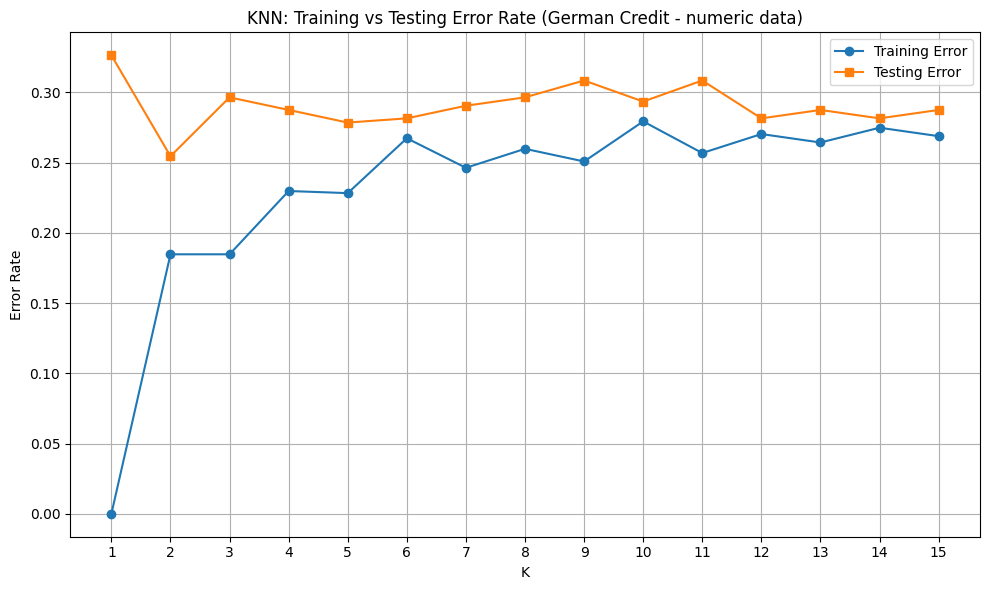


=== Classifier comparison using best K for KNN (numeric data) ===
(Using KNN with K = 2)

Running KNN with k=2 ...
Running Categorical Naive Bayes ...
Running Decision Tree ... (might take a bit)

MODEL: KNN (k=2)
Confusion Matrix (rows=actual, cols=predicted; 1=Good, 2=Bad):
[[222  15]
 [ 70  27]]
Accuracy: 0.7455
Precision (class=2/Bad): 0.6429
Recall    (class=2/Bad): 0.2784
F-score   (harmonic mean of P & R): 0.3885

MODEL: Categorical NB
Confusion Matrix (rows=actual, cols=predicted; 1=Good, 2=Bad):
[[196  41]
 [ 48  49]]
Accuracy: 0.7335
Precision (class=2/Bad): 0.5444
Recall    (class=2/Bad): 0.5052
F-score   (harmonic mean of P & R): 0.5241

MODEL: Decision Tree
Confusion Matrix (rows=actual, cols=predicted; 1=Good, 2=Bad):
[[181  56]
 [ 47  50]]
Accuracy: 0.6916
Precision (class=2/Bad): 0.4717
Recall    (class=2/Bad): 0.5155
F-score   (harmonic mean of P & R): 0.4926

#############################################
 COMPARISON OF CLASSIFIERS (by F-score) 
######################

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. LOAD DATA (NUMERIC VERSION)
# ==========================================
# Assumes german.data-numeric is in the same folder.
data = pd.read_csv("german.data-numeric", header=None, delim_whitespace=True)
X = data.iloc[:, :-1].values      # features
y = data.iloc[:, -1].values       # labels (1 = good, 2 = bad)

# ==========================================
# 2. TRAIN / TEST SPLIT (2/3 train, 1/3 test)
# ==========================================
np.random.seed(42)
indices = np.random.permutation(len(X))
split = int(len(X) * 2 / 3)

train_idx = indices[:split]
test_idx = indices[split:]

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

# ==========================================
# 3. KNN (NO SKLEARN)
# ==========================================
def knn_predict_one(x, X_train, y_train, k):
    """Predict label for a single sample x using KNN."""
    dists = np.sqrt(np.sum((X_train - x) ** 2, axis=1))
    k_idx = np.argsort(dists)[:k]
    labels, counts = np.unique(y_train[k_idx], return_counts=True)
    return labels[np.argmax(counts)]

def knn_predict(X_eval, X_train, y_train, k):
    """Predict labels for all samples in X_eval using KNN."""
    return np.array([knn_predict_one(x, X_train, y_train, k) for x in X_eval])

# ==========================================
# 4. CATEGORICAL NAIVE BAYES (NO SKLEARN)
#    Treats each feature as discrete (counts + Laplace smoothing)
# ==========================================
class CategoricalNBManual:
    def __init__(self, alpha=1.0):
        self.alpha = alpha

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        self.classes_, class_counts = np.unique(y, return_counts=True)
        self.class_counts_ = dict(zip(self.classes_, class_counts))
        self.class_log_prior_ = {
            c: np.log(count / len(y)) for c, count in self.class_counts_.items()
        }

        n_features = X.shape[1]
        self.n_features_ = n_features

        # Unique values per feature (over entire training set)
        self.feature_values_ = [np.unique(X[:, j]) for j in range(n_features)]
        self.n_values_ = [len(vals) for vals in self.feature_values_]

        # For each class and feature, store counts of each value
        self.feature_counts_ = {
            c: [dict() for _ in range(n_features)] for c in self.classes_
        }

        for c in self.classes_:
            X_c = X[y == c]
            for j in range(n_features):
                vals, counts = np.unique(X_c[:, j], return_counts=True)
                d = self.feature_counts_[c][j]
                for v, cnt in zip(vals, counts):
                    d[v] = cnt

        return self

    def _log_likelihood(self, x, c):
        log_prob = 0.0
        alpha = self.alpha
        class_count = self.class_counts_[c]

        for j in range(self.n_features_):
            v = x[j]
            counts_dict = self.feature_counts_[c][j]
            n_values = self.n_values_[j]
            count_v = counts_dict.get(v, 0)
            # Laplace-smoothed probability
            prob = (count_v + alpha) / (class_count + alpha * n_values)
            log_prob += np.log(prob)

        return log_prob

    def predict(self, X):
        X = np.asarray(X)
        preds = []
        for x in X:
            class_log_post = {}
            for c in self.classes_:
                log_prior = self.class_log_prior_[c]
                log_lik = self._log_likelihood(x, c)
                class_log_post[c] = log_prior + log_lik
            preds.append(max(class_log_post, key=class_log_post.get))
        return np.array(preds)

# ==========================================
# 5. DECISION TREE (ID3-LIKE, NO SKLEARN)
# ==========================================
def entropy(y):
    values, counts = np.unique(y, return_counts=True)
    probs = counts / len(y)
    return -np.sum(probs * np.log2(probs + 1e-9))

def split_dataset(X, y, feature, threshold):
    left_mask = X[:, feature] <= threshold
    right_mask = X[:, feature] > threshold
    return (X[left_mask], y[left_mask]), (X[right_mask], y[right_mask])

def best_split(X, y):
    best_gain = -1
    best_feature, best_threshold = None, None
    current_entropy = entropy(y)
    n_features = X.shape[1]

    for feature in range(n_features):
        thresholds = np.unique(X[:, feature])
        for t in thresholds:
            (X_left, y_left), (X_right, y_right) = split_dataset(X, y, feature, t)
            if len(y_left) == 0 or len(y_right) == 0:
                continue

            p = len(y_left) / len(y)
            gain = current_entropy - (p * entropy(y_left) + (1 - p) * entropy(y_right))

            if gain > best_gain:
                best_gain = gain
                best_feature = feature
                best_threshold = t

    return best_feature, best_threshold

class DecisionTreeManual:
    def fit(self, X, y):
        self.tree = self._build_tree(X, y)

    def _build_tree(self, X, y):
        # If all labels are the same, return that label (leaf)
        if len(np.unique(y)) == 1:
            return y[0]

        feature, threshold = best_split(X, y)

        # If no split improves information gain, return majority class
        if feature is None:
            return np.bincount(y).argmax()

        node = {
            "feature": feature,
            "threshold": threshold
        }

        (X_left, y_left), (X_right, y_right) = split_dataset(X, y, feature, threshold)
        node["left"] = self._build_tree(X_left, y_left)
        node["right"] = self._build_tree(X_right, y_right)

        return node

    def _predict_one(self, x, node):
        if not isinstance(node, dict):
            return node  # leaf

        if x[node["feature"]] <= node["threshold"]:
            return self._predict_one(x, node["left"])
        else:
            return self._predict_one(x, node["right"])

    def predict(self, X):
        return np.array([self._predict_one(x, self.tree) for x in X])

# ==========================================
# 6. METRICS (NO SKLEARN)
# ==========================================
def confusion_matrix_manual(y_true, y_pred):
    """
    Confusion matrix for classes 1 and 2:
    [[actual=1,pred=1,  actual=1,pred=2],
     [actual=2,pred=1,  actual=2,pred=2]]
    """
    matrix = np.zeros((2, 2), dtype=int)
    for t, p in zip(y_true, y_pred):
        matrix[int(t) - 1, int(p) - 1] += 1
    return matrix

def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def precision(y_true, y_pred, positive_class=2):
    tp = np.sum((y_pred == positive_class) & (y_true == positive_class))
    fp = np.sum((y_pred == positive_class) & (y_true != positive_class))
    return tp / (tp + fp + 1e-9)

def recall(y_true, y_pred, positive_class=2):
    tp = np.sum((y_pred == positive_class) & (y_true == positive_class))
    fn = np.sum((y_pred != positive_class) & (y_true == positive_class))
    return tp / (tp + fn + 1e-9)

def f_score(p, r):
    return 2 * (p * r) / (p + r + 1e-9)

# ==========================================
# 7. PART B: KNN K=1..15 ERROR CURVES + AUTO BEST K
# ==========================================
print("=== KNN error vs K (1 to 15) and auto-select best K (numeric data) ===")

K_values = range(1, 16)
train_errors = []
test_errors = []

for k in K_values:
    y_pred_train = knn_predict(X_train, X_train, y_train, k)
    train_error = np.mean(y_pred_train != y_train)
    train_errors.append(train_error)

    y_pred_test = knn_predict(X_test, X_train, y_train, k)
    test_error = np.mean(y_pred_test != y_test)
    test_errors.append(test_error)

    print(f"K={k:2d} | Train Error={train_error:.4f} | Test Error={test_error:.4f}")

best_k_index = int(np.argmin(test_errors))
best_k = list(K_values)[best_k_index]
print(f"\n>>> Best K based on minimum test error: K = {best_k} "
      f"(Test Error = {test_errors[best_k_index]:.4f})")

plt.figure(figsize=(10, 6))
plt.plot(list(K_values), train_errors, marker='o', label='Training Error')
plt.plot(list(K_values), test_errors, marker='s', label='Testing Error')

plt.title("KNN: Training vs Testing Error Rate (German Credit - numeric data)")
plt.xlabel("K")
plt.ylabel("Error Rate")
plt.xticks(list(K_values))
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# ==========================================
# 8. PART A: USE BEST K IN KNN + CATEGORICAL NB + DT
# ==========================================
print("\n=== Classifier comparison using best K for KNN (numeric data) ===")
print(f"(Using KNN with K = {best_k})")

print(f"\nRunning KNN with k={best_k} ...")
knn_pred = knn_predict(X_test, X_train, y_train, best_k)

print("Running Categorical Naive Bayes ...")
nb = CategoricalNBManual(alpha=1.0)
nb.fit(X_train, y_train)
nb_pred = nb.predict(X_test)

print("Running Decision Tree ... (might take a bit)")
dt = DecisionTreeManual()
dt.fit(X_train, y_train)
dt_pred = dt.predict(X_test)

models_preds = {
    f"KNN (k={best_k})": knn_pred,
    "Categorical NB": nb_pred,
    "Decision Tree": dt_pred
}

results = {}

for name, preds in models_preds.items():
    print("\n==============================")
    print(f"MODEL: {name}")
    cm = confusion_matrix_manual(y_test, preds)
    print("Confusion Matrix (rows=actual, cols=predicted; 1=Good, 2=Bad):")
    print(cm)

    acc = accuracy(y_test, preds)
    prec = precision(y_test, preds, positive_class=2)
    rec = recall(y_test, preds, positive_class=2)
    f = f_score(prec, rec)

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision (class=2/Bad): {prec:.4f}")
    print(f"Recall    (class=2/Bad): {rec:.4f}")
    print(f"F-score   (harmonic mean of P & R): {f:.4f}")

    results[name] = {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f_score": f
    }

print("\n#############################################")
print(" COMPARISON OF CLASSIFIERS (by F-score) ")
print("#############################################")
for name, stats in sorted(results.items(), key=lambda x: x[1]["f_score"], reverse=True):
    print(f"{name:18s} | Acc={stats['accuracy']:.4f}  "
          f"P={stats['precision']:.4f}  R={stats['recall']:.4f}  F={stats['f_score']:.4f}")
